# 01 Data Exploration & Sanity Check
This notebook verifies that the environment, dataset, and our custom data processing logic in `src/data.py` are working correctly.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Add src to path
sys.path.append("..")
from src.data import load_ecthr, mask_paragraphs

In [2]:
print("Loading dataset...")
dataset = load_ecthr()
print(f"Train: {len(dataset['train'])} | Val: {len(dataset['validation'])} | Test: {len(dataset['test'])}")

ex = dataset['train'][0]
print("\nExample structure:")
print(f"Keys: {ex.keys()}")
print(f"Labels: {ex['labels']}")
print(f"Number of paragraphs: {len(ex['text'])}")

Loading dataset...


Filter:   0%|          | 0/9000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 8988 | Val: 992 | Test: 1000

Example structure:
Keys: dict_keys(['text', 'labels'])
Labels: [4]
Number of paragraphs: 83


Avg paragraphs: 23.7
Max paragraphs: 558
Min paragraphs: 5


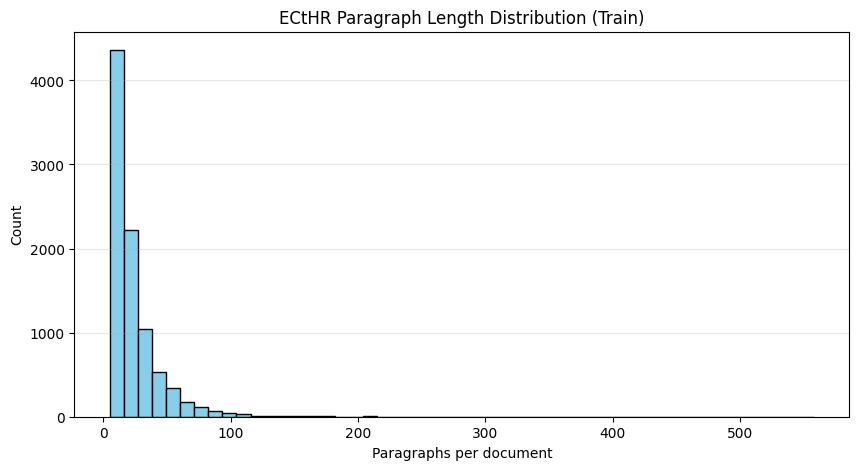

In [3]:
lengths = [len(ex['text']) for ex in dataset['train']]
print(f"Avg paragraphs: {np.mean(lengths):.1f}")
print(f"Max paragraphs: {np.max(lengths)}")
print(f"Min paragraphs: {np.min(lengths)}")

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Paragraphs per document")
plt.ylabel("Count")
plt.title("ECtHR Paragraph Length Distribution (Train)")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [4]:
print("Verifying Masking Logic...")
full = ex['text']
masked = mask_paragraphs(full)
print(f"Full document: {len(full)} paragraphs")
print(f"Masked document: {len(masked)} paragraphs")
print(f"Remaining ratio: {len(masked)/len(full):.2%}")

assert len(masked) < len(full), "Masking failed to remove any paragraphs!"
assert len(masked) >= 1, "Masking removed all paragraphs!"
print("\nSanity check passed!")

Verifying Masking Logic...
Full document: 83 paragraphs
Masked document: 51 paragraphs
Remaining ratio: 61.45%

Sanity check passed!
